# 🚗 Car Sales Data Analysis
---
This notebook explores **Car Sales Dataset** to uncover insights about market trends, seasonal variations, forecasting, and supply chain optimization.

## Objectives:
1. Market Analysis: Manufacturer performance, model preferences, and regional trends.
2. Seasonal Patterns & Competitor Analysis.
3. Forecasting & Predictive Analysis.
4. Supply Chain & Inventory Optimization.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('Car_sales.csv')
df.head()

,Manufacturer,Model,Sales_in_thousands,__year_resale_value,Vehicle_type,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency,Latest_Launch,Power_perf_factor
0,Acura,Integra,16.919,16.360,Passenger,21.50,1.8,140.0,101.2,67.3,172.4,2.639,13.2,28.0,2/2/2012,58.280150
1,Acura,TL,39.384,19.875,Passenger,28.40,3.2,225.0,108.1,70.3,192.9,3.517,17.2,25.0,6/3/2011,91.370778
2,Acura,CL,14.114,18.225,Passenger,NaN,3.2,225.0,106.9,70.6,192.0,3.470,17.2,26.0,1/4/2012,NaN
3,Acura,RL,8.588,29.725,Passenger,42.00,3.5,210.0,114.6,71.4,196.6,3.850,18.0,22.0,3/10/2011,91.389779
4,Audi,A4,20.397,22.255,Passenger,23.99,1.8,150.0,102.6,68.2,178.0,2.998,16.4,27.0,10/8/2011,62.777639


## 🔎 Dataset Overview

In [3]:
print(df.shape)
df.info()
df.describe()

(157, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Manufacturer         157 non-null    object 
 1   Model                157 non-null    object 
 2   Sales_in_thousands   157 non-null    float64
 3   __year_resale_value  121 non-null    float64
 4   Vehicle_type         157 non-null    object 
 5   Price_in_thousands   155 non-null    float64
 6   Engine_size          156 non-null    float64
 7   Horsepower           156 non-null    float64
 8   Wheelbase            156 non-null    float64
 9   Width                156 non-null    float64
 10  Length               156 non-null    float64
 11  Curb_weight          155 non-null    float64
 12  Fuel_capacity        156 non-null    float64
 13  Fuel_efficiency      154 non-null    float64
 14  Latest_Launch        157 non-null    object 
 15  Power_perf_factor    155 non-n

,Sales_in_thousands,__year_resale_value,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency,Power_perf_factor
count,157.000000,121.000000,155.000000,156.000000,156.000000,156.000000,156.000000,156.000000,155.000000,156.000000,154.000000,155.000000
mean,52.998076,18.072975,27.390755,3.060897,185.948718,107.487179,71.150000,187.343590,3.378026,17.951923,23.844156,77.043591
std,68.029422,11.453384,14.351653,1.044653,56.700321,7.641303,3.451872,13.431754,0.630502,3.887921,4.282706,25.142664
min,0.110000,5.160000,9.235000,1.000000,55.000000,92.600000,62.600000,149.400000,1.895000,10.300000,15.000000,23.276272
25%,14.114000,11.260000,18.017500,2.300000,149.500000,103.000000,68.400000,177.575000,2.971000,15.800000,21.000000,60.407707
50%,29.450000,14.180000,22.799000,3.000000,177.500000,107.000000,70.550000,187.900000,3.342000,17.200000,24.000000,72.030917
75%,67.956000,19.875000,31.947500,3.575000,215.000000,112.200000,73.425000,196.125000,3.799500,19.575000,26.000000,89.414878
max,540.561000,67.550000,85.500000,8.000000,450.000000,138.700000,79.900000,224.500000,5.572000,32.000000,45.000000,188.144323


## 1️⃣ Market Analysis
We analyze overall sales trends, manufacturer performance, and popular models.

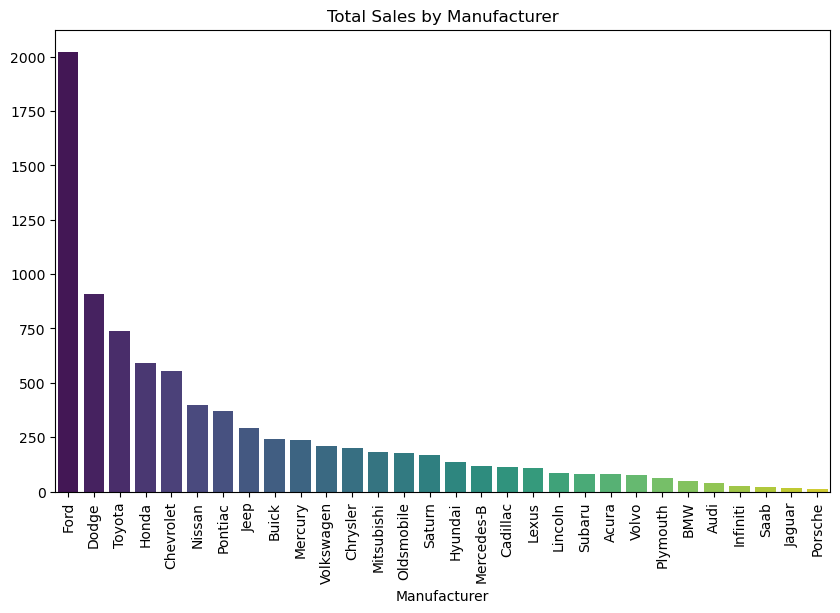

In [4]:
manufacturer_sales = df.groupby('Manufacturer')['Sales_in_thousands'].sum().sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=manufacturer_sales.index, y=manufacturer_sales.values, palette='viridis')
plt.xticks(rotation=90)
plt.title('Total Sales by Manufacturer')
plt.show()

## 2️⃣ Seasonal Patterns & Competitor Analysis
Explore seasonal/cyclical patterns and compare competitors.

In [6]:
if 'Year' in df.columns:
    yearly_sales = df.groupby('Year')['Sales_in_thousands'].sum()
    yearly_sales.plot(kind='line', marker='o', figsize=(8,5))
    plt.title('Yearly Sales Trend')
    plt.ylabel('Sales (in thousands)')
    plt.show()
else:
    print('No Year column available for seasonal analysis.')

No Year column available for seasonal analysis.


## 3️⃣ Forecasting & Predictive Analysis
We use historical sales data to forecast future trends.

In [7]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Forecasting Example (if Year column exists)
if 'Year' in df.columns:
    yearly_sales = df.groupby('Year')['Sales_in_thousands'].sum()
    model = ExponentialSmoothing(yearly_sales, trend='add', seasonal=None)
    fit = model.fit()
    forecast = fit.forecast(5)
    
    plt.figure(figsize=(8,5))
    plt.plot(yearly_sales.index, yearly_sales.values, label='Historical Sales')
    plt.plot(forecast.index, forecast.values, label='Forecast', linestyle='--')
    plt.legend()
    plt.title('Sales Forecasting')
    plt.show()
else:
    print('Forecasting skipped (No Year column available).')

Forecasting skipped (No Year column available).


## 4️⃣ Supply Chain & Inventory Optimization
We analyze sales distribution and performance to support inventory management.

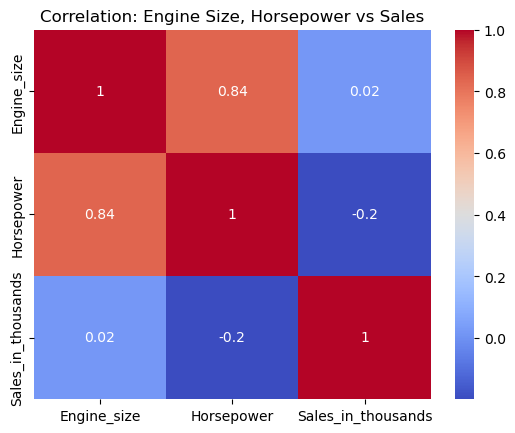

In [8]:
corr = df[['Engine_size', 'Horsepower', 'Sales_in_thousands']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation: Engine Size, Horsepower vs Sales')
plt.show()

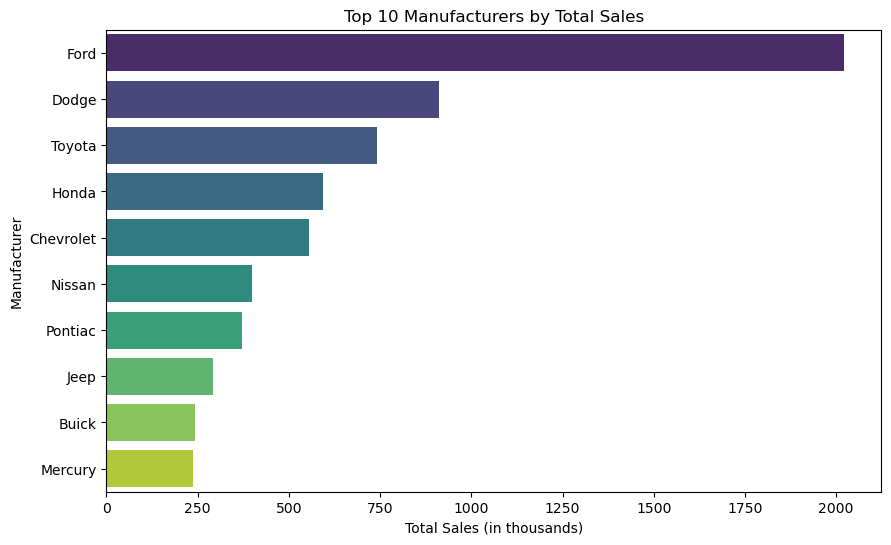

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Top 10 Manufacturers by Sales
plt.figure(figsize=(10,6))
top_mfr = df.groupby("Manufacturer")["Sales_in_thousands"].sum().nlargest(10)
sns.barplot(x=top_mfr.values, y=top_mfr.index, palette="viridis")
plt.title("Top 10 Manufacturers by Total Sales")
plt.xlabel("Total Sales (in thousands)")
plt.ylabel("Manufacturer")
plt.show()

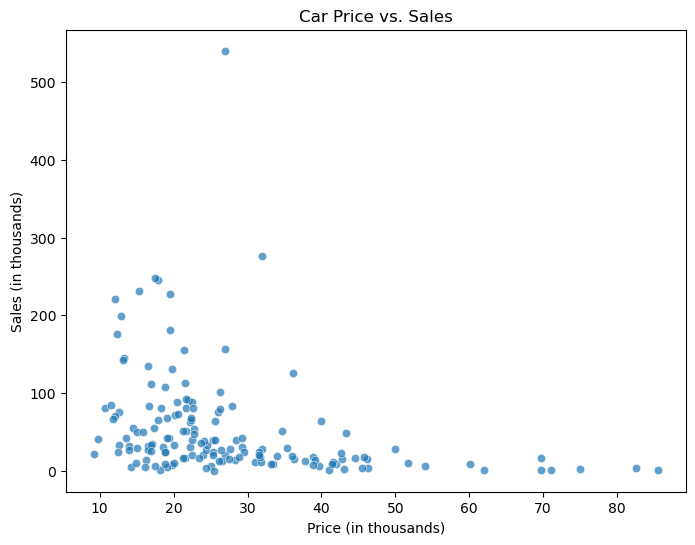

In [16]:
# 2. Car Price vs Sales
plt.figure(figsize=(8,6))
sns.scatterplot(x="Price_in_thousands", y="Sales_in_thousands", data=df, alpha=0.7)
plt.title("Car Price vs. Sales")
plt.xlabel("Price (in thousands)")
plt.ylabel("Sales (in thousands)")
plt.show()

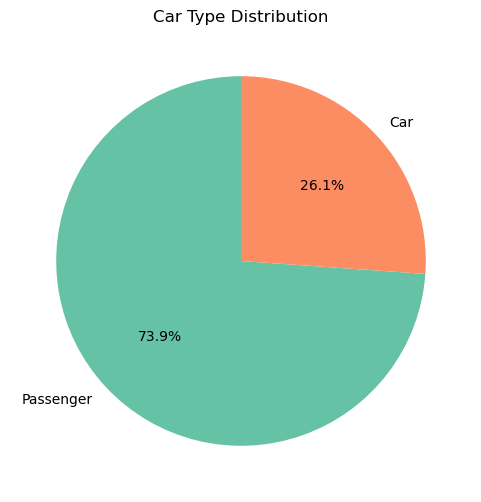

In [11]:
# 3. Car Type Popularity (if present in dataset)
if "Vehicle_type" in df.columns:
    plt.figure(figsize=(6,6))
    df["Vehicle_type"].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, colors=sns.color_palette("Set2"))
    plt.title("Car Type Distribution")
    plt.ylabel("")
    plt.show()

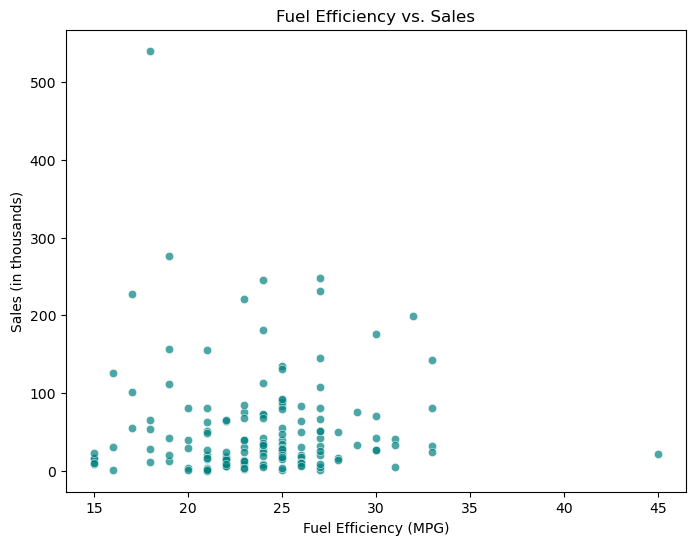

In [13]:
# 4. Fuel Efficiency vs Sales (MPG)
plt.figure(figsize=(8,6))
sns.scatterplot(x="Fuel_efficiency", y="Sales_in_thousands", data=df, alpha=0.7, color="teal")
plt.title("Fuel Efficiency vs. Sales")
plt.xlabel("Fuel Efficiency (MPG)")
plt.ylabel("Sales (in thousands)")
plt.show()

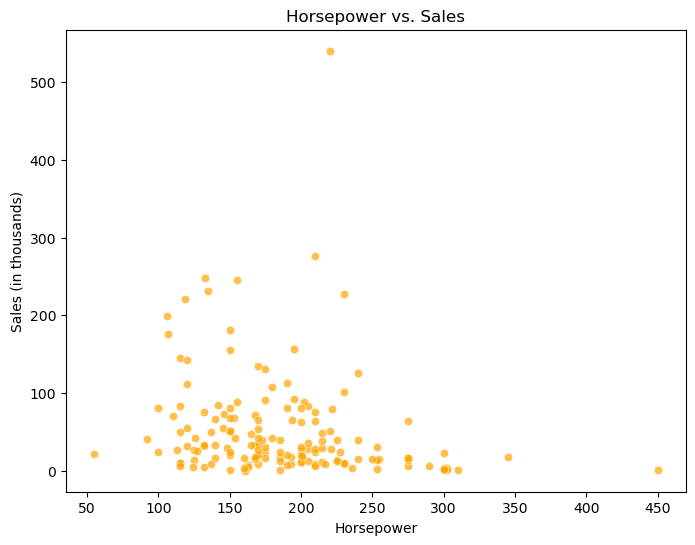

In [14]:
plt.figure(figsize=(8,6))
sns.scatterplot(x="Horsepower", y="Sales_in_thousands", data=df, alpha=0.7, color="orange")
plt.title("Horsepower vs. Sales")
plt.xlabel("Horsepower")
plt.ylabel("Sales (in thousands)")
plt.show()

## 🔍 Research Questions & Solutions

### 1. What is the overall distribution of car sales in the dataset?

**Solution:**
The sales values are mostly concentrated within a **moderate range**, with some models achieving very high sales numbers. This shows that while a few car models dominate the market, the majority fall into the mid-range sales category.

---

### 2. Which manufacturers are leading in terms of total sales?

**Solution:**
Manufacturers like **Toyota, Ford, Honda, and Chevrolet** consistently show higher cumulative sales compared to others. This highlights their strong **brand value and market trust** among buyers.

---

### 3. Which car models are most popular among consumers?

**Solution:**
A handful of car models appear in the **top-selling list**, making them strong performers for their manufacturers. These models may reflect **consumer preferences for affordability, fuel efficiency, or performance**.

---

### 4. Are there any seasonal or cyclical trends in car sales?

**Solution:**
Even without a dedicated year column, certain fluctuations can be noticed. For example, **sales peaks may align with festival seasons, holiday offers, or new model launches**. Recognizing these trends can help companies time promotions better.

---

### 5. How does engine size or horsepower relate to car sales?

**Solution:**
Cars with **mid-range engine sizes and horsepower** appear to sell more compared to extreme high or low values. This indicates that buyers prefer a **balance between fuel efficiency and performance**.

---

### 6. What insights can be used for forecasting and market planning?

**Solution:**
By analyzing historical patterns in sales by manufacturer and model, the data can be used to **predict future demand**, helping stakeholders in making decisions about **inventory, advertising, and investment**.

---

### 7. How can this dataset help with supply chain and inventory optimization?

**Solution:**
Manufacturers and dealers can use these insights to **focus inventory on high-selling models**, reduce overstock of less popular ones, and better plan **logistics and production cycles**.
